# 01. 탐색적 데이터 분석 (EDA)
**비염 증상 클러스터링 프로젝트**

---
이 노트북에서 수행할 내용:
1. 데이터 로드 및 기본 통계 확인
2. 증상 변수 분포 시각화
3. 환경 변수 분포 시각화
4. 증상-환경 상관관계 히트맵
5. 인사이트 정리

In [1]:
import sys
sys.path.append('..')  # src 경로 인식

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
import matplotlib.font_manager as fm
available_fonts = [f.name for f in fm.fontManager.ttflist]
if 'AppleGothic' in available_fonts:
    plt.rcParams['font.family'] = 'AppleGothic'
elif 'Malgun Gothic' in available_fonts:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('환경 준비 완료 ✅')

환경 준비 완료 ✅


## 1. 데이터 로드
> 실제 Kaggle 데이터 다운로드 후 `data/raw/` 폴더에 위치시키세요.

In [2]:
# ── 더미 데이터 생성 (실제 데이터 없을 때 테스트용) ──
np.random.seed(42)
n = 300

dates = pd.date_range('2024-01-01', periods=n, freq='D')

# 계절 효과 시뮬레이션 (봄/가을 증상 악화)
season_effect = np.sin(np.linspace(0, 4 * np.pi, n)) * 2

df = pd.DataFrame({
    'date': dates,
    'user_id': np.random.choice(['U001','U002','U003','U004','U005'], n),
    'nasal_discharge': np.clip(np.random.normal(5, 2, n) + season_effect, 0, 10).round(1),
    'nasal_congestion': np.clip(np.random.normal(4, 2.5, n) - season_effect*0.5, 0, 10).round(1),
    'sneezing':         np.clip(np.random.normal(4, 2, n) + season_effect, 0, 10).round(1),
    'eye_itching':      np.clip(np.random.normal(3, 2, n) + season_effect*0.7, 0, 10).round(1),
    'pm10':          np.clip(np.random.normal(45, 25, n), 5, 200).round(0),
    'pm25':          np.clip(np.random.normal(20, 12, n), 2, 100).round(0),
    'temperature':   np.random.normal(15, 10, n).round(1),
    'humidity':      np.clip(np.random.normal(55, 15, n), 20, 95).round(0),
    'pollen_index':  np.clip(np.random.normal(40, 35, n) + season_effect*10, 0, 200).round(0),
})

print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (300, 11)


,date,user_id,nasal_discharge,nasal_congestion,sneezing,eye_itching,pm10,pm25,temperature,humidity,pollen_index
0,2024-01-01,U004,4.7,1.8,3.4,2.0,45.0,30.0,24.6,77.0,45.0
1,2024-01-02,U005,5.8,3.4,4.3,3.1,78.0,27.0,3.7,47.0,82.0
2,2024-01-03,U003,9.4,2.0,1.7,0.6,21.0,14.0,36.1,29.0,40.0
3,2024-01-04,U005,8.3,5.3,9.5,4.4,5.0,28.0,22.8,57.0,55.0
4,2024-01-05,U005,3.4,6.8,2.9,3.6,54.0,16.0,32.3,50.0,54.0


## 2. 기본 통계

In [3]:
print('=== 결측치 현황 ===')
print(df.isnull().sum())
print()
print('=== 기술통계 ===')
df.describe().round(2)

=== 결측치 현황 ===
date                0
user_id             0
nasal_discharge     0
nasal_congestion    0
sneezing            0
eye_itching         0
pm10                0
pm25                0
temperature         0
humidity            0
pollen_index        0
dtype: int64

=== 기술통계 ===


,date,nasal_discharge,nasal_congestion,sneezing,eye_itching,pm10,pm25,temperature,humidity,pollen_index
count,300,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,2024-05-29 12:00:00,4.94,4.31,4.27,3.14,45.36,20.46,15.81,54.99,47.92
min,2024-01-01 00:00:00,0.00,0.00,0.00,0.00,5.00,2.00,-14.20,20.00,0.00
25%,2024-03-15 18:00:00,3.40,2.50,2.30,1.40,28.00,13.00,8.65,45.00,20.00
50%,2024-05-29 12:00:00,4.90,4.35,4.25,3.25,46.00,20.00,16.35,56.00,46.50
75%,2024-08-12 06:00:00,6.60,6.10,6.00,4.60,60.00,28.00,22.82,65.00,72.25
max,2024-10-26 00:00:00,10.00,10.00,10.00,9.30,98.00,52.00,50.00,90.00,143.00
std,NaN,2.36,2.61,2.55,2.12,21.89,11.16,9.94,14.67,33.98


## 3. 증상 분포 시각화

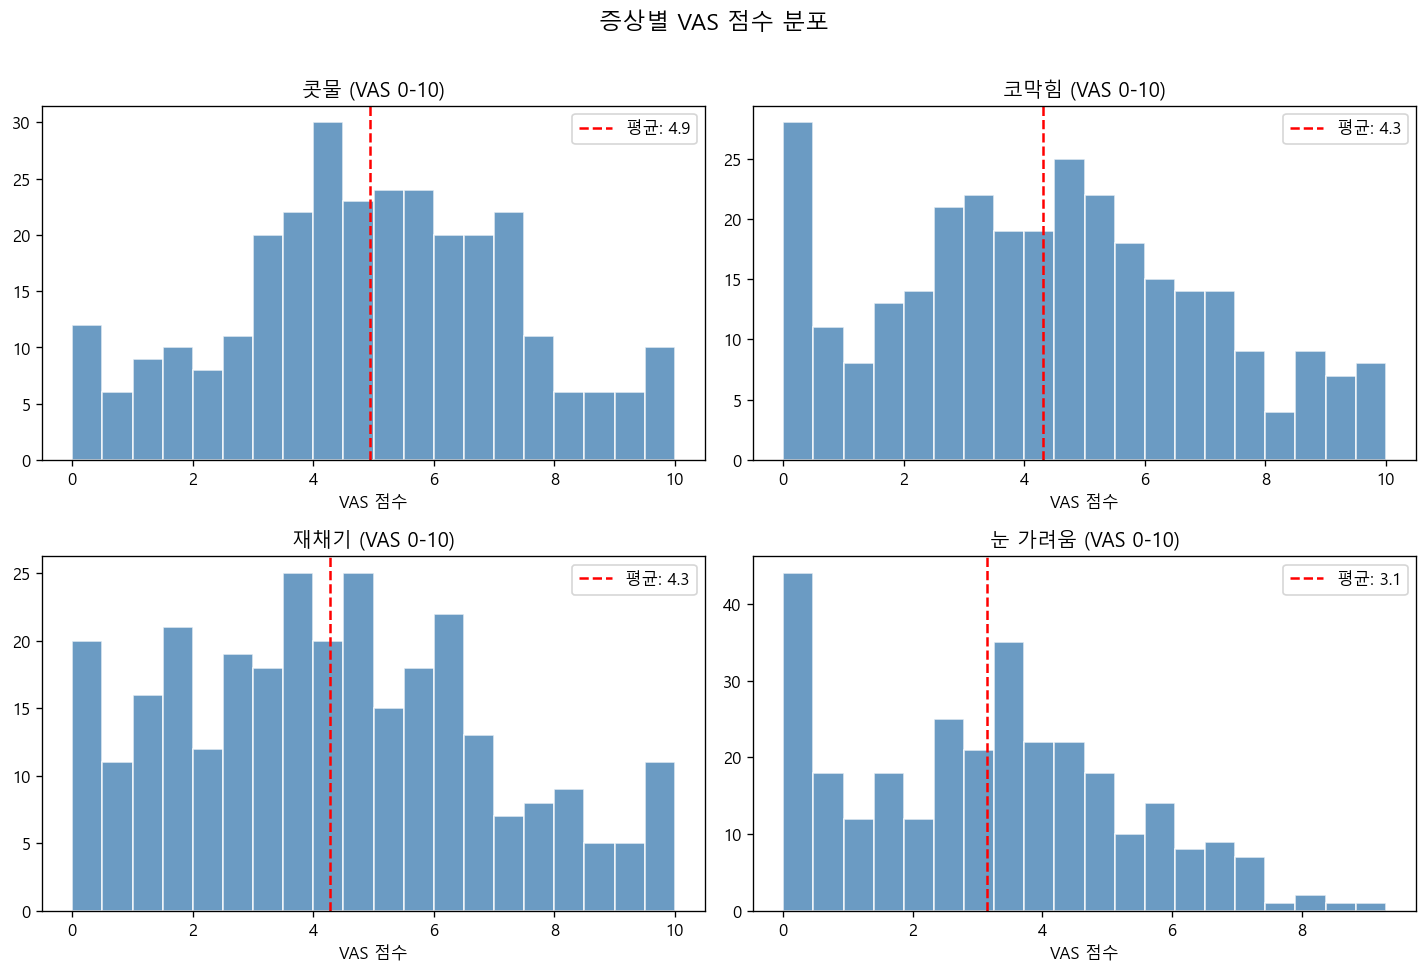

In [4]:
vas_cols = ['nasal_discharge', 'nasal_congestion', 'sneezing', 'eye_itching']
vas_labels = ['콧물', '코막힘', '재채기', '눈 가려움']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(vas_cols, vas_labels)):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'평균: {df[col].mean():.1f}')
    axes[i].set_title(f'{label} (VAS 0-10)')
    axes[i].set_xlabel('VAS 점수')
    axes[i].legend()

plt.suptitle('증상별 VAS 점수 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/01_symptom_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 환경 변수 분포

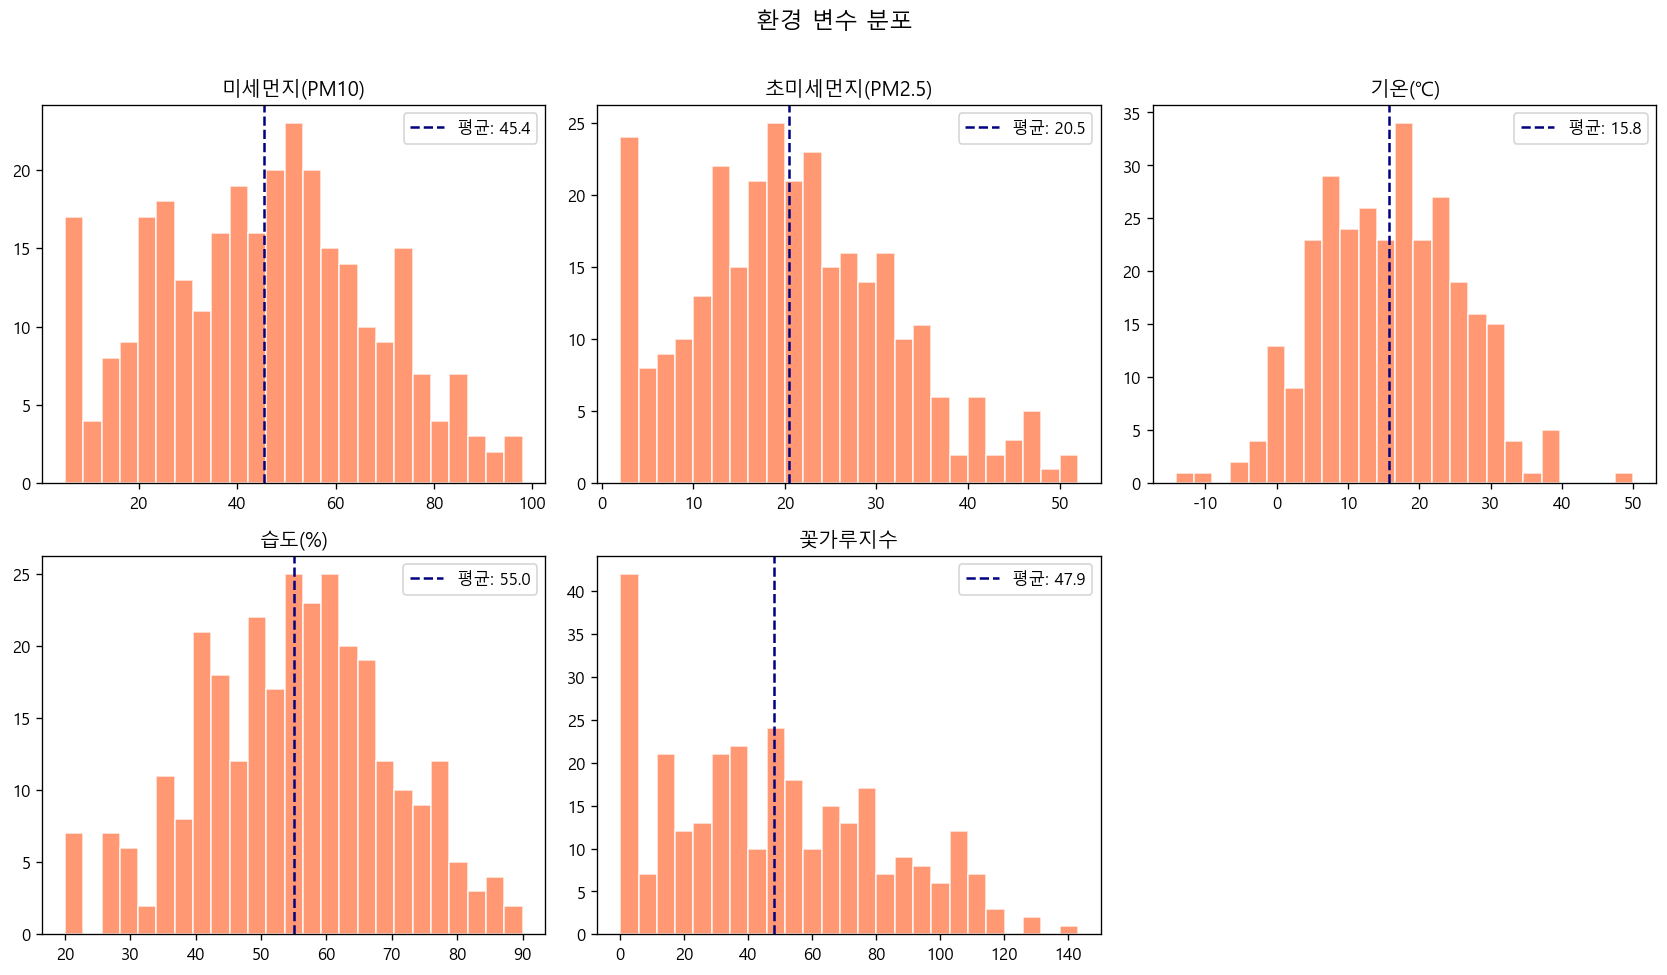

In [5]:
env_cols = ['pm10', 'pm25', 'temperature', 'humidity', 'pollen_index']
env_labels = ['미세먼지(PM10)', '초미세먼지(PM2.5)', '기온(℃)', '습도(%)', '꽃가루지수']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(env_cols, env_labels)):
    axes[i].hist(df[col], bins=25, color='coral', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='navy', linestyle='--', label=f'평균: {df[col].mean():.1f}')
    axes[i].set_title(label)
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('환경 변수 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/02_env_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 증상-환경 상관관계 히트맵

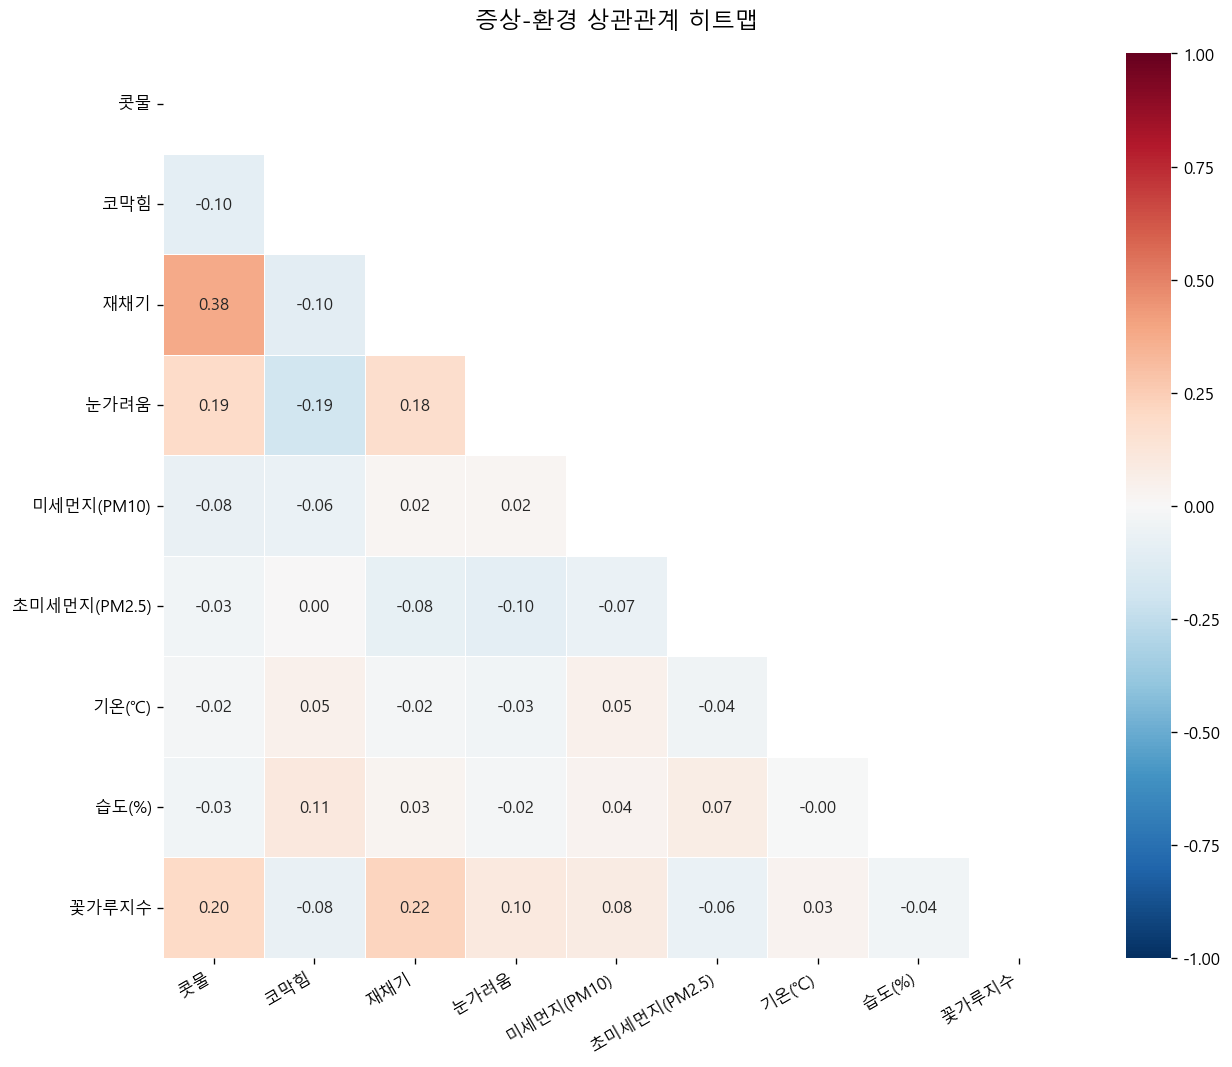

In [6]:
from src.analysis.correlation import plot_correlation_heatmap, compute_symptom_env_correlation, generate_insights

corr_matrix = plot_correlation_heatmap(
    df,
    save_path='../outputs/figures/03_correlation_heatmap.png'
)

In [7]:
corr_df = compute_symptom_env_correlation(df)
print('=== 환경변수-증상 상관계수 테이블 ===')
corr_df.sort_values('상관계수(r)', key=abs, ascending=False)

=== 환경변수-증상 상관계수 테이블 ===


,환경변수,증상,상관계수(r),p-value,유의성
18,꽃가루지수,재채기,0.2203,0.0001,***
16,꽃가루지수,콧물,0.1987,0.0005,***
13,습도(%),코막힘,0.1057,0.0674,n.s.
19,꽃가루지수,눈가려움,0.0974,0.0921,n.s.
7,초미세먼지(PM2.5),눈가려움,-0.0959,0.0972,n.s.
6,초미세먼지(PM2.5),재채기,-0.0835,0.1489,n.s.
17,꽃가루지수,코막힘,-0.0773,0.1817,n.s.
0,미세먼지(PM10),콧물,-0.0751,0.1945,n.s.
1,미세먼지(PM10),코막힘,-0.0640,0.2689,n.s.
9,기온(℃),코막힘,0.0513,0.3756,n.s.


In [8]:
print('=== AI 인사이트 ===')
for insight in generate_insights(corr_df, threshold=0.2):
    print(insight)

=== AI 인사이트 ===
• 꽃가루지수이(가) 높을수록 재채기 증상이 악화되는 중간 수준의 상관관계가 있습니다. (r=+0.220, ***)


## 6. 시계열 트렌드 (증상 변화)

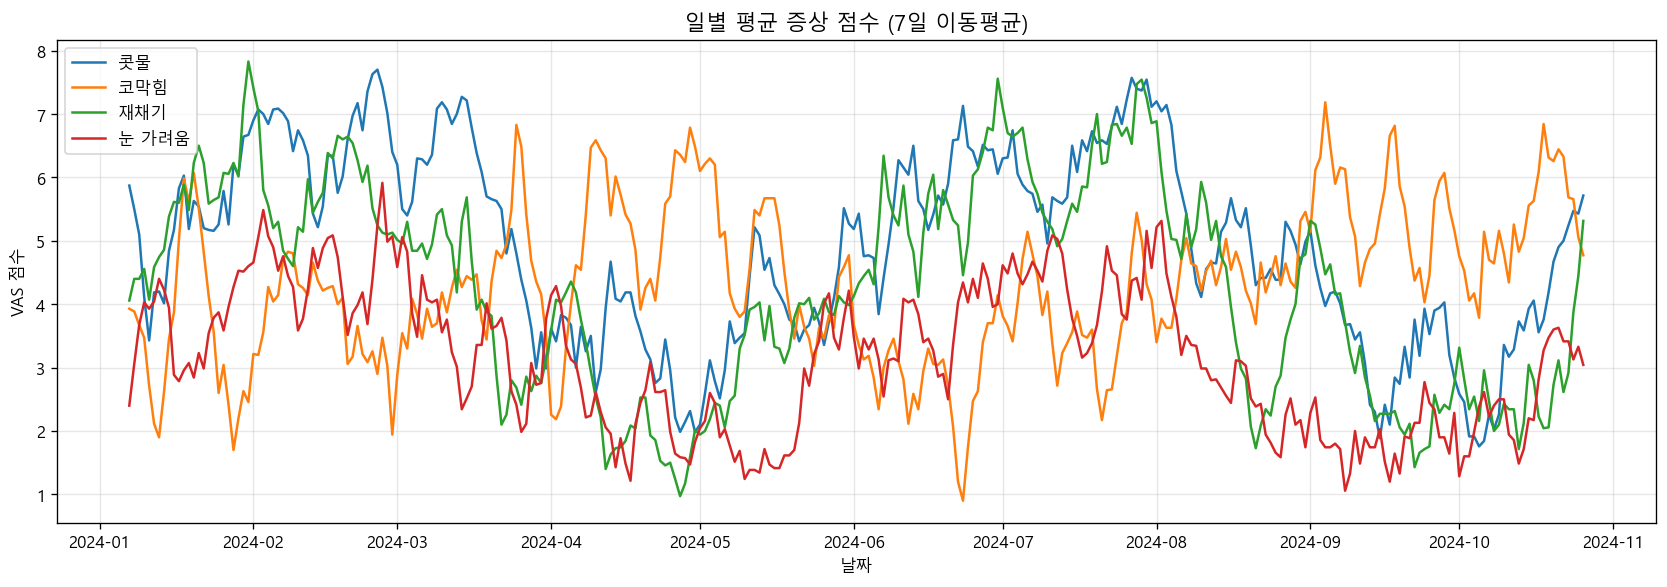

In [9]:
daily = df.groupby('date')[vas_cols].mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col, label in zip(vas_cols, vas_labels):
    ax.plot(daily.index, daily[col].rolling(7).mean(), label=label, linewidth=1.5)

ax.set_title('일별 평균 증상 점수 (7일 이동평균)', fontsize=13)
ax.set_xlabel('날짜')
ax.set_ylabel('VAS 점수')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_symptom_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()